# Time Series Windows Resampling Exercises

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

## Exercise: Resampling

We can aggregate time series by resampling the points on a coarser time level. 

* Use the `resample` function to get the data corresponding to monthly averages using the bikes dataset

The code will then display the `temperature` time series for the monthly averages. 

In [7]:
bikes = pd.read_csv("data/bikes.csv", parse_dates=["date"], index_col="date")
bikes.head()
# Your code here


,temperature,humidity,windspeed,count
date,,,,
2011-01-03,2.716070,45.715346,21.414957,120.0
2011-01-04,2.896673,54.267219,15.136882,108.0
2011-01-05,4.235654,45.697702,17.034578,82.0
2011-01-06,3.112643,50.237349,10.091568,88.0
2011-01-07,2.723918,49.144928,15.738204,148.0


/var/folders/48/sg6ygl_12s3d3_qq60vknbgr0000gn/T/ipykernel_58876/163181133.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bikes_monthly = bikes.resample("M").mean()


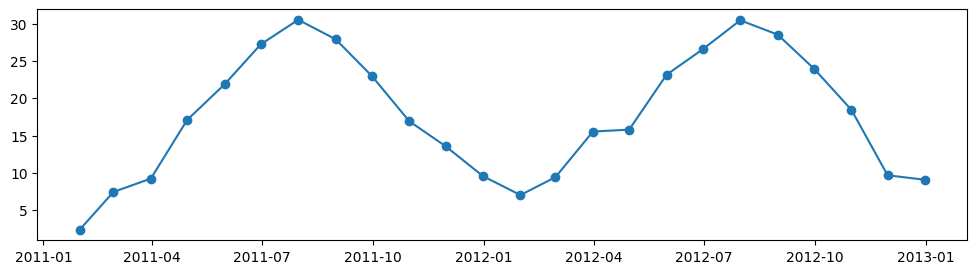

In [11]:
bikes_monthly = bikes.resample("M").mean()

plt.figure(figsize=(12, 3))
plt.plot(bikes_monthly['temperature'], "-o")

We will now plot the humidity variable, to appreciate how it looks. 

<Axes: xlabel='date'>

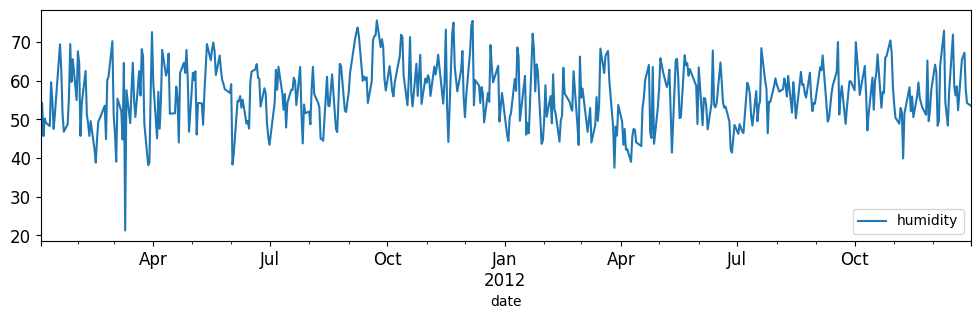

In [12]:
bikes.plot(y="humidity", figsize=(12, 3), fontsize=12)

### Exercise: Weekly averages
Use now the `resample` function to compute the weekly averages for the whole bikes dataset.

The code will then display the variable `humidity`.

Do you observe any differences comparing this plot to the one from the cell before?

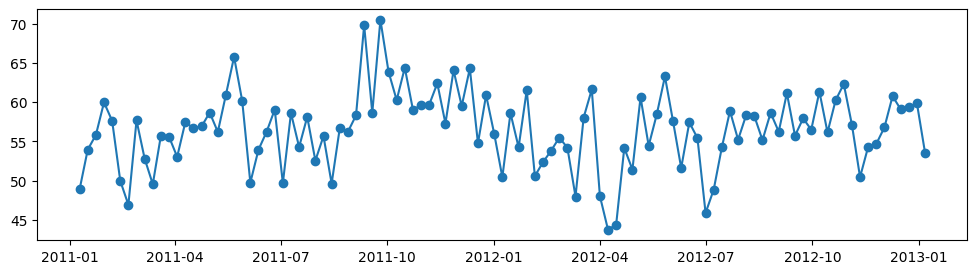

In [13]:
# Your code here
bikes_weeks = bikes.resample("W").mean()
plt.figure(figsize=(12, 3))
plt.plot(bikes_weeks.humidity, "-o")

### Exercise: Upsampling
Let's try upsampling now. Use the `resample` function to get a time series with data points sampled every 6h and then use the function `ffill` (forward fill) to fill all the NaN values in the dataframe. 

The code will then plot the upsampled humidity variable.

Investigate what ffill does. Do you think this is a reasonable approach for all our variables in the bikes dataset?

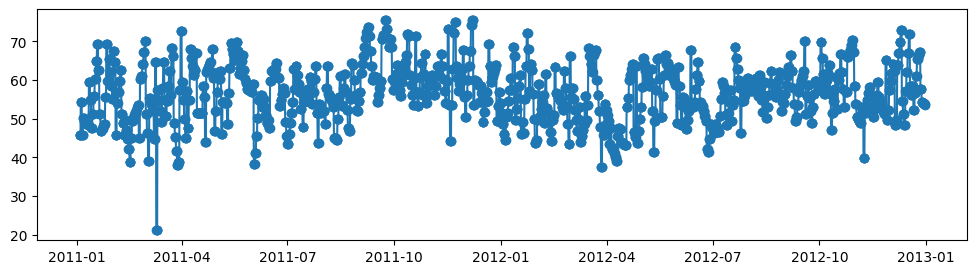

In [15]:
# Your code here
# bikes_6h = bikes.resample("6H").mean()
bikes_6h = bikes.resample("0.25D").ffill()
plt.figure(figsize=(12, 3))
plt.plot(bikes_6h.humidity, "-o")

## Parsing custom date formats

When you loaded the bikes dataset, Pandas automatically detected the format of the dates for you.
This might often "just work" but there often will be cases where you need to be careful about parsing and might have to do it yourself.

Load the data `NZAlcoholConsumption` and have a look at it without specifying a column to parse for dates. 

In [16]:
alcohol_consumption = pd.read_csv("data/NZAlcoholConsumption.csv")
alcohol_consumption.head()

,DATE,TotalBeer,TotalSpirits,TotalWine
0,2004Q3,3.135,1.746,2.318
1,2000Q1,2.957,1.097,1.486
2,2006Q1,3.027,1.443,2.141
3,2000Q3,2.798,1.496,1.844
4,2011Q3,2.865,2.482,2.704


This dataset contains data aggregated by quarters, the timestamp is formatted in a string where the first 4 characters represent the year and the last two the quarter. 
To transform the timestamps in dates that pandas can directly use, you can write a parser function. 


### Exercise: parsing quarter
Write a function `parse_quarter` that takes a string of the form `YYYYQN` and convert it to `pandas.Timestamp` object. Use the following conversion for the quarters:

* Q1 --> mar 31
* Q2 --> jun 30
* Q3 --> sep 20
* Q4 --> dec 31

Hint: the below code cell may help

In [17]:
import re

year, qn = re.search(r"^(20[0-9][0-9])(Q[1-4])$", "2004Q3").group(1, 2)
print(year)
print(qn)

2004
Q3


In [18]:
import re


# Your code here
def parse_quarter(string):
    """
    Converts a string from the format YYYYQN in datetime object at the end of quarter N.
    """

    # Note: you could also just retrieve the first four elements of the string
    # and the last one... Regex is fun but often not necessary
    year, qn = re.search(r"^(20[0-9][0-9])(Q[1-4])$", string).group(1, 2)

    # year and qn will be strings, pd.datetime expects integers.
    year = int(year)

    date = None

    if qn == "Q1":
        date = pd.Timestamp(year, 3, 31)
    elif qn == "Q2":
        date = pd.Timestamp(year, 6, 30)
    elif qn == "Q3":
        date = pd.Timestamp(year, 9, 30)
    else:
        date = pd.Timestamp(year, 12, 31)

    return date


# Check that it works!
print(parse_quarter("2000Q3"))  # should show 2000-09-20 00:00:00

2000-09-30 00:00:00


### Giving the parser to pandas

Pandas can parse dates using a custom made parser such as the one you just defined. For this just specify your function in the `date_parser` option.

In [23]:
# reload the data using your parser, set the index to the date
alcohol_consumption = pd.read_csv(
    "data/NZAlcoholConsumption.csv",
    parse_dates=["DATE"],
    date_parser=parse_quarter,
    index_col="DATE",
)
alcohol_consumption.sort_index(inplace=True)
alcohol_consumption.head()


/var/folders/48/sg6ygl_12s3d3_qq60vknbgr0000gn/T/ipykernel_58876/2678166250.py:2: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  alcohol_consumption = pd.read_csv(


,TotalBeer,TotalSpirits,TotalWine
DATE,,,
2000-03-31,2.957,1.097,1.486
2000-06-30,2.823,1.309,1.915
2000-09-30,2.798,1.496,1.844
2000-12-31,3.997,1.810,2.808
2001-03-31,3.037,1.240,1.287


### Exercise: Display the time series

Now, have a look at the consumption of wine and beer by showing both on the same figure. You just need to define the wine and beer variables later used for the plotting. Discuss the two time series.

<Axes: xlabel='DATE'>

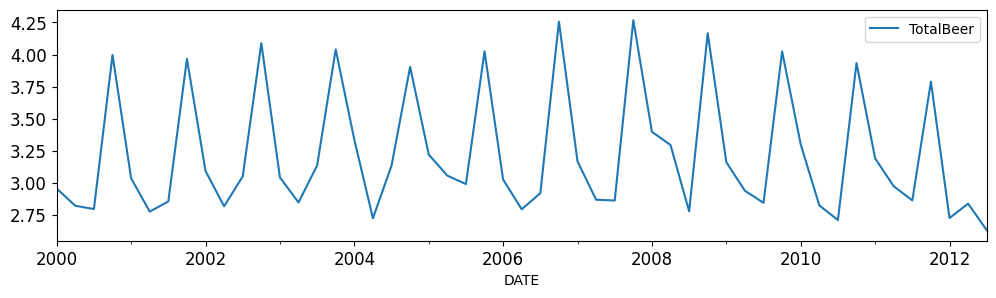

In [ ]:
# Your code here
alcohol_consumption.plot(y="TotalBeer", figsize=(12, 3), fontsize=12)



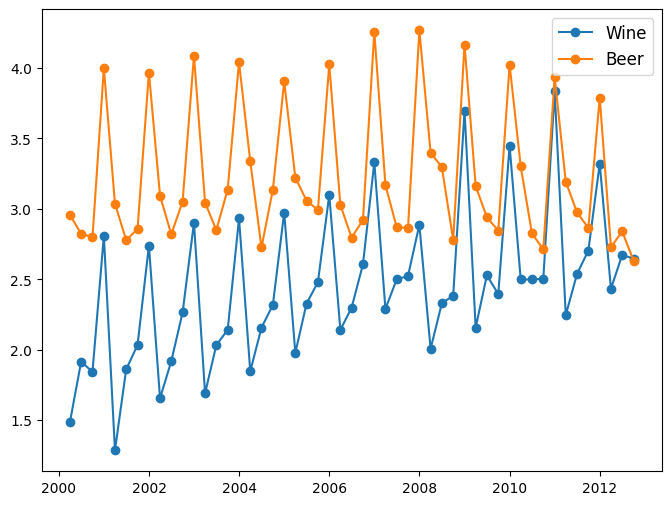

In [26]:

# Your code here
wine = alcohol_consumption.TotalWine
beer = alcohol_consumption.TotalBeer

plt.figure(figsize=(8, 6))
plt.plot(wine, "-o", label="Wine")
plt.plot(beer, "-o", label="Beer")
plt.legend(fontsize=12)

The plots show that the two time series have similar patterns in terms of seasonality but different trends.
Both show that alcohol consumption is maximum in the last quarter of the year. 
The average beer consumption seems stable during the years, while the wine consumption seems to be steadily increasing. 

### Exercise: resample the data per year (12 months) 
Downsample the data per year (12 months average) using `resample`. Can you observe any trends?

In [31]:
# Your code here

# alcohol_consumption_year=alcohol_consumption.resample("Y").mean()
# alcohol_consumption_year.plot(y=["TotalBeer", "TotalWine"], figsize=(12, 3), fontsize=12)


# bikes_weeks = bikes.resample("W").mean()
# plt.figure(figsize=(12, 3))
# plt.plot(bikes_weeks.humidity, "-o")

/var/folders/48/sg6ygl_12s3d3_qq60vknbgr0000gn/T/ipykernel_58876/1140116019.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  alc_yearly = alcohol_consumption.resample("12M").mean()


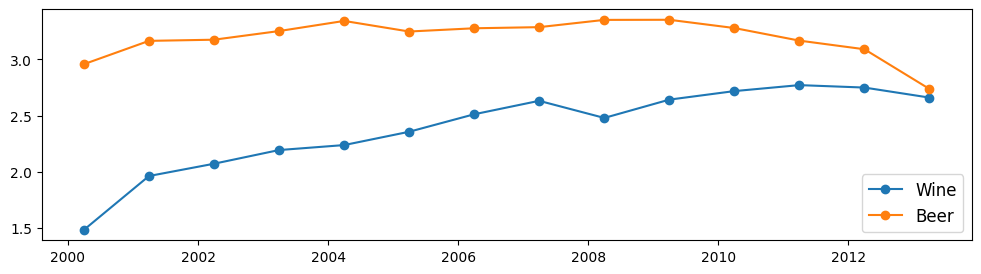

In [30]:
alc_yearly = alcohol_consumption.resample("12M").mean()

plt.figure(figsize=(12, 3))
plt.plot(alc_yearly.TotalWine, "-o", label="Wine")
plt.plot(alc_yearly.TotalBeer, "-o", label="Beer")
plt.legend(fontsize=12)